In [1]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
from scipy.stats import dunnett
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
import plot_of_experiment_data as ped


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

In [6]:
# for screening result 

# tarsal result 
fpath = f'{os.getcwd()}/data/tarsal_screening.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_tarsal = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_tarsal[s] = df
    
fpath = f'{os.getcwd()}/data/labial_screening.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_labial = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_labial[s] = df

,group,comparison,U,p_raw,asterisk,p_adj
0,SS35412 meteor,SS35412 meteor vs. Control,24.0,0.005577,*,0.044613
1,SS29813 justice,SS29813 justice vs. Control,23.5,0.007601,*,0.044613
2,SS31063 earmuff,SS31063 earmuff vs. Control,24.0,0.005709,*,0.044613
3,SS43899 aDN1,SS43899 aDN1 vs. Control,23.5,0.007601,*,0.044613
4,SS31705 snake,SS31705 snake vs. Control,24.0,0.005709,*,0.044613
5,SS39923 broom,SS39923 broom vs. Control,24.0,0.005709,*,0.044613
6,SS38535 mothership,SS38535 mothership vs. Control,24.0,0.005709,*,0.044613
7,SS31366 mesa,SS31366 mesa vs. Control,23.5,0.007437,*,0.044613


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

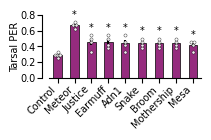

In [13]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# ======================================
# 공통 레이아웃
# ======================================

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32

BAR_H = 1.0

colors = ['#13739E', '#952B7E']

fontsize = 7
lp = 2

bar_spacing = 0.15
bar_width = 0.075


# ======================================
# 데이터 정리
# ======================================

cols = [
    'control',
    'SS35412 meteor',
    'SS29813 justice',
    'SS31063 earmuff',
    'SS43899 aDN1',
    'SS31705 snake',
    'SS39923 broom',
    'SS38535 mothership',
    'SS31366 mesa'
]

mean_mat = pd.DataFrame(
    index=cols,
    columns=['sugar+geosmin'],
    dtype=float
)

std_mat = pd.DataFrame(
    index=cols,
    columns=['sugar+geosmin'],
    dtype=float
)

mean_mat['sugar+geosmin'] = (
    data_df_tarsal['sugar+geosmin'][cols]
    .mean(axis=0)
)

std_mat['sugar+geosmin'] = ped.std_err(
    data_df_tarsal['sugar+geosmin'][cols]
)


# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(2, BAR_H),
    constrained_layout=False
)


# ======================================
# Bar + scatter
# ======================================

xloc = ped.draw_bar_with_points(
    ax=ax,

    conditions=cols,
    groups=['sugar+geosmin'],

    get_values=lambda cond, group:
        data_df_tarsal[group][cond].values,

    get_mean=lambda cond, group:
        mean_mat.loc[cond, group],

    get_err=lambda cond, group:
        std_mat.loc[cond, group],

    bar_width=bar_width,
    bar_spacing=bar_spacing,

    colors=[colors[1]],

    edgecolor='black',
    linewidth=.5,

    capsize=0,

    point_facecolor='white',
    point_edgecolor='black',
    point_lw=.3,
    point_size=5,
    point_alpha=.9
)


# ======================================
# Statistics
# Mann–Whitney U
# H1: genotype > control
#
# geosmin suppression이 사라지면
# genotype PER가 control보다 높아지는 방향
# ======================================

df_stat = data_df_tarsal['sugar+geosmin'][cols]

control = df_stat['control'].dropna()

results = []

for col in cols:

    if col == 'control':
        continue

    group = df_stat[col].dropna()

    stat, p = mannwhitneyu(
        group,
        control,
        alternative='greater',
        method='auto'
    )

    results.append({
        'group': col,
        'comparison': col + ' vs. Control',
        'U': stat,
        'p_raw': p
    })

results = pd.DataFrame(results)
results['asterisk'] = results['p_raw'].apply(ped.pval_to_asterisks)

# ======================================
# Holm correction
# ======================================

results['p_adj'] = multipletests(
    results['p_raw'],
    method='holm'
)[1]

results['asterisk'] = results['p_adj'].apply(
    ped.pval_to_asterisks
)

display(results)


# ======================================
# Significance marks
# ======================================

max_vals = (
    data_df_tarsal['sugar+geosmin'][cols]
    .max(axis=0)
)


for i, c in enumerate(cols[1:], start=1):

    ast = results.loc[
        results['group'] == c,
        'asterisk'
    ].iloc[0]

    if ast != 'ns':

        ypos = max_vals[c] + .03

        ax.text(
            xloc[i],
            ypos,
            ast,
            fontsize=7,
            ha='center',
            va='bottom'
        )


# ======================================
# Axis formatting
# ======================================

xlabel = [
    x.split(" ")[-1]
    for x in cols
]

xlabel[0] = 'control'

ax.set_xticks(
    xloc,
    [x.capitalize() for x in xlabel],
    rotation=45,
    ha='right'
)

ax.set_yticks(
    np.arange(0, 1, .2)
)

ax.set_ylabel(
    'Tarsal PER',
    labelpad=lp
)

ax.set_ylim([
    0,
    .8
])

ax.set_xlim(
    -bar_spacing / 2,
    xloc[-1] + bar_spacing / 2
)

ax.spines[['top', 'right']].set_visible(False)

ax.spines['left'].set_position(
    ('outward', 5)
)

ax.tick_params(
    pad=1
)

ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5


# ======================================
# Layout
# ======================================

fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)


# ======================================
# Save
# ======================================

# plt.savefig(
#     'figures/kir2.1_tarsal_av1a1_PER_only_hit.svg'
# )

,group,comparison,U,p_raw,asterisk
0,"SS31362 gallinule, trogon","SS31362 gallinule, trogon vs. Control",23.0,0.011079,*
1,SS36658 planter,SS36658 planter vs. Control,17.5,0.136469,ns
2,SS29458 kitty,SS29458 kitty vs. Control,17.5,0.136469,ns
3,SS44937 bamboo,SS44937 bamboo vs. Control,17.5,0.136469,ns
4,SS39923 broom,SS39923 broom vs. Control,17.5,0.136469,ns
5,SS31345 FDG,SS31345 FDG vs. Control,27.0,0.079854,ns
6,SS32404 spray,SS32404 spray vs. Control,17.5,0.136469,ns
7,SS42322 diatom,SS42322 diatom vs. Control,17.5,0.136469,ns


,group,comparison,U,p_raw,asterisk,p_adj
0,"SS31362 gallinule, trogon","SS31362 gallinule, trogon vs. Control",23.0,0.011079,ns,0.088629
1,SS36658 planter,SS36658 planter vs. Control,17.5,0.136469,ns,0.818813
2,SS29458 kitty,SS29458 kitty vs. Control,17.5,0.136469,ns,0.818813
3,SS44937 bamboo,SS44937 bamboo vs. Control,17.5,0.136469,ns,0.818813
4,SS39923 broom,SS39923 broom vs. Control,17.5,0.136469,ns,0.818813
5,SS31345 FDG,SS31345 FDG vs. Control,27.0,0.079854,ns,0.558978
6,SS32404 spray,SS32404 spray vs. Control,17.5,0.136469,ns,0.818813
7,SS42322 diatom,SS42322 diatom vs. Control,17.5,0.136469,ns,0.818813


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

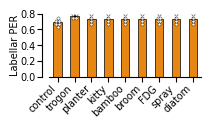

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


# ======================================
# 공통 레이아웃
# ======================================

LEFT = 0.22
RIGHT = 0.98
TOP = 0.95
BOTTOM = 0.32

BAR_H = 1.0

fontsize = 7
lp = 2

bar_spacing = 0.15
bar_width = 0.075

colors = ['#4CAF50', '#E68613']


# ======================================
# 데이터 정리
# ======================================

cols = [
    'control',
    'SS31362 gallinule, trogon',
    'SS36658 planter',
    'SS29458 kitty',
    'SS44937 bamboo',
    'SS39923 broom',
    'SS31345 FDG',
    'SS32404 spray',
    'SS42322 diatom'
]


mean_mat = pd.DataFrame(
    index=cols,
    columns=['sugar+geosmin'],
    dtype=float
)

std_mat = pd.DataFrame(
    index=cols,
    columns=['sugar+geosmin'],
    dtype=float
)


mean_mat['sugar+geosmin'] = (
    data_df_labial['sugar+geosmin'][cols]
    .mean(axis=0)
)

std_mat['sugar+geosmin'] = ped.std_err(
    data_df_labial['sugar+geosmin'][cols]
)


# ======================================
# Figure
# ======================================

fig, ax = plt.subplots(
    1, 1,
    figsize=(2, BAR_H),
    constrained_layout=False
)


# ======================================
# Bar + scatter
# ======================================

xloc = ped.draw_bar_with_points(
    ax=ax,

    conditions=cols,
    groups=['sugar+geosmin'],

    get_values=lambda cond, group:
        data_df_labial[group][cond].values,

    get_mean=lambda cond, group:
        mean_mat.loc[cond, group],

    get_err=lambda cond, group:
        std_mat.loc[cond, group],

    bar_width=bar_width,
    bar_spacing=bar_spacing,

    colors=[colors[1]],

    edgecolor='black',
    linewidth=.5,

    capsize=0,

    point_facecolor='white',
    point_edgecolor='black',
    point_lw=.3,
    point_size=5,
    point_alpha=.9
)


# ======================================
# Statistics
# Mann–Whitney U
# H1: genotype > control
# ======================================

df_stat = data_df_labial['sugar+geosmin'][cols]

control = df_stat['control'].dropna()

results = []

for col in cols:

    if col == 'control':
        continue

    group = df_stat[col].dropna()

    stat, p = mannwhitneyu(
        group,
        control,
        alternative='greater',
        method='auto'
    )

    results.append({
        'group': col,
        'comparison': col + ' vs. Control',
        'U': stat,
        'p_raw': p
    })


results = pd.DataFrame(results)

results['asterisk'] = results['p_raw'].apply(
    ped.pval_to_asterisks
)

display(results)


# ======================================
# Holm correction
# ======================================

results['p_adj'] = multipletests(
    results['p_raw'],
    method='holm'
)[1]

results['asterisk'] = results['p_adj'].apply(
    ped.pval_to_asterisks
)

display(results)


# ======================================
# Significance marks
# ======================================

max_vals = (
    data_df_labial['sugar+geosmin'][cols]
    .max(axis=0)
)


for i, c in enumerate(cols[1:], start=1):

    ast = results.loc[
        results['group'] == c,
        'asterisk'
    ].iloc[0]

    if ast != 'ns':

        ypos = max_vals[c] + .03

        ax.text(
            xloc[i],
            ypos,
            ast,
            fontsize=7,
            ha='center',
            va='bottom'
        )


# ======================================
# Axis formatting
# ======================================

xlabel = [
    x.split(" ")[-1]
    for x in cols
]

xlabel[0] = 'control'


ax.set_xticks(
    xloc,
    xlabel,
    rotation=45,
    ha='right'
)


ax.set_yticks(
    np.arange(0, 1, .2)
)


ax.set_ylabel(
    'Labellar PER',
    labelpad=lp
)


ax.set_ylim([
    0,
    0.8
])


ax.set_xlim(
    -bar_spacing / 2,
    xloc[-1] + bar_spacing / 2
)


ax.spines[['top', 'right']].set_visible(False)

ax.spines['left'].set_position(
    ('outward', 5)
)

ax.tick_params(
    pad=1
)

ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5


# ======================================
# Layout
# ======================================

fig.subplots_adjust(
    left=LEFT,
    right=RIGHT,
    top=TOP,
    bottom=BOTTOM
)


# ======================================
# Save
# ======================================

# plt.savefig(
#     'figures/kir2.1_labial_av1a1_PER_only_hit.svg'
# )

KeyError: "['SS29813 justice', 'SS31063 earmuff', 'SS43899 aDN1', 'SS31705 snake', 'SS39923 broom', 'SS38535 mothership', 'SS31366 mesa'] not in index"